# Notebook 06 — Feature Engineering

## Objectif

Créer des variables dérivées pour **enrichir le signal** et améliorer le pouvoir prédictif du modèle ML.

## Features créées

| Feature | Formule | Intuition physique |
|---|---|---|
| `delta_temp` | `process_temp - air_temp` | Gradient thermique (> 12 K → risque HDF) |
| `puissance_w` | `torque × rpm × 2π / 60` | Puissance mécanique (W) |
| `ratio_torque_rpm` | `torque / rpm` | Indicateur de sollicitation |
| `tool_wear_bin` | `neuf / use / critique` | Catégorisation usure outil |
| `torque_x_wear` | `torque × tool_wear` | Interaction charge × fatigue |
| `energy_per_piece_wh` | `puissance × cycle / 3600` | Consommation par pièce |
| Encodage `Type` | OneHot (L/M/H) | Gamme produit |
| Encodage `usine` | OneHot (FR-01/ES-01) | Effet site |

## Rattachement grille MSPR

Enrichissement des features pour dépasser le seuil **PR-AUC > 0.5** du notebook 07.


## 1. Imports et chargement silver

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ROOT = Path.cwd().parent
SILVER_DIR = PROJECT_ROOT / "data" / "silver"
GOLD_DIR = PROJECT_ROOT / "data" / "gold"
GOLD_DIR.mkdir(parents=True, exist_ok=True)

frames = [pd.read_parquet(f) for f in sorted(SILVER_DIR.glob("*.parquet"))]
df = pd.concat(frames, ignore_index=True)
print(f"Silver : {df.shape}")
df.head(2)

Silver : (10070, 17)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,timestamp,usine,pays
0,319,L47498,L,297.8,308.4,1512,39.596343,189,0,0,0,0,0,0,2025-10-01 06:18:00.648612845,ES-01,Espagne
1,1150,L48329,L,297.2,308.1,1446,38.351136,118,0,0,0,0,0,0,2025-10-01 06:24:32.591039184,ES-01,Espagne


## 2. Features physiques

In [2]:
# --- Gradient thermique ---
df["delta_temp"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# --- Puissance mecanique ---
omega = df["Rotational speed [rpm]"] * 2 * np.pi / 60
df["puissance_w"] = df["Torque [Nm]"] * omega

# --- Ratio couple / vitesse (sollicitation) ---
df["ratio_torque_rpm"] = df["Torque [Nm]"] / df["Rotational speed [rpm]"]

# --- Energie par piece (cycle nominal 60s) ---
df["energy_per_piece_wh"] = df["puissance_w"] * 60 / 3600

print("Nouvelles features physiques :")
print(df[["delta_temp", "puissance_w", "ratio_torque_rpm", "energy_per_piece_wh"]].describe().round(3))

Nouvelles features physiques :
       delta_temp  puissance_w  ratio_torque_rpm  energy_per_piece_wh
count   10070.000    10070.000         10070.000            10070.000
mean       10.001     6283.089             0.027              104.718
std         1.059     1193.901             0.009               19.898
min         5.700     -349.387            -0.002               -5.823
25%         9.200     5558.919             0.021               92.649
50%         9.800     6283.516             0.027              104.725
75%        11.000     7010.564             0.033              116.843
max        14.800    18277.659             0.065              304.628


## 3. Binning (catégorisation)

In [3]:
def classify_wear(x):
    if x < 50:   return "neuf"
    if x < 150:  return "use"
    return "critique"

df["tool_wear_bin"] = df["Tool wear [min]"].apply(classify_wear)

print("\nRepartition tool_wear_bin :")
print(df["tool_wear_bin"].value_counts())

print("\nTaux de panne par categorie d'usure :")
print(df.groupby("tool_wear_bin")["Machine failure"].agg(["mean", "sum", "count"]).round(4))


Repartition tool_wear_bin :
tool_wear_bin
use         4743
critique    3165
neuf        2162
Name: count, dtype: int64

Taux de panne par categorie d'usure :
                 mean  sum  count
tool_wear_bin                    
critique       0.0556  176   3165
neuf           0.0217   47   2162
use            0.0230  109   4743


## 4. Features d'interaction

In [4]:
df["torque_x_wear"] = df["Torque [Nm]"] * df["Tool wear [min]"]
df["temp_x_rpm"] = df["Process temperature [K]"] * df["Rotational speed [rpm]"]

print(df[["torque_x_wear", "temp_x_rpm"]].describe().round(2))

       torque_x_wear  temp_x_rpm
count       10070.00    10070.00
mean         4448.18   475856.76
std          2823.52    51120.96
min          -170.86   358809.60
25%          2132.75   441836.50
50%          4177.16   465910.40
75%          6376.13   498530.25
max         17452.30   685062.80


## 5. Encodage catégoriel (OneHot)

In [5]:
df = pd.get_dummies(df, columns=["Type", "usine", "tool_wear_bin"], prefix=["type", "usine", "wear"])

cols_encoded = [c for c in df.columns if c.startswith(("type_", "usine_", "wear_"))]
print(f"Colonnes encodees : {cols_encoded}")
print()
df[cols_encoded].head()

Colonnes encodees : ['type_H', 'type_L', 'type_M', 'usine_ES-01', 'usine_FR-01', 'wear_critique', 'wear_neuf', 'wear_use']



,type_H,type_L,type_M,usine_ES-01,usine_FR-01,wear_critique,wear_neuf,wear_use
0,False,True,False,True,False,True,False,False
1,False,True,False,True,False,False,False,True
2,False,True,False,True,False,False,False,True
3,False,True,False,True,False,True,False,False
4,False,False,True,True,False,False,True,False


## 6. Visualisation : nouvelles features vs cible

/tmp/ipykernel_38309/1133055729.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_38309/1133055729.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_38309/1133055729.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_38309/1133055729.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])


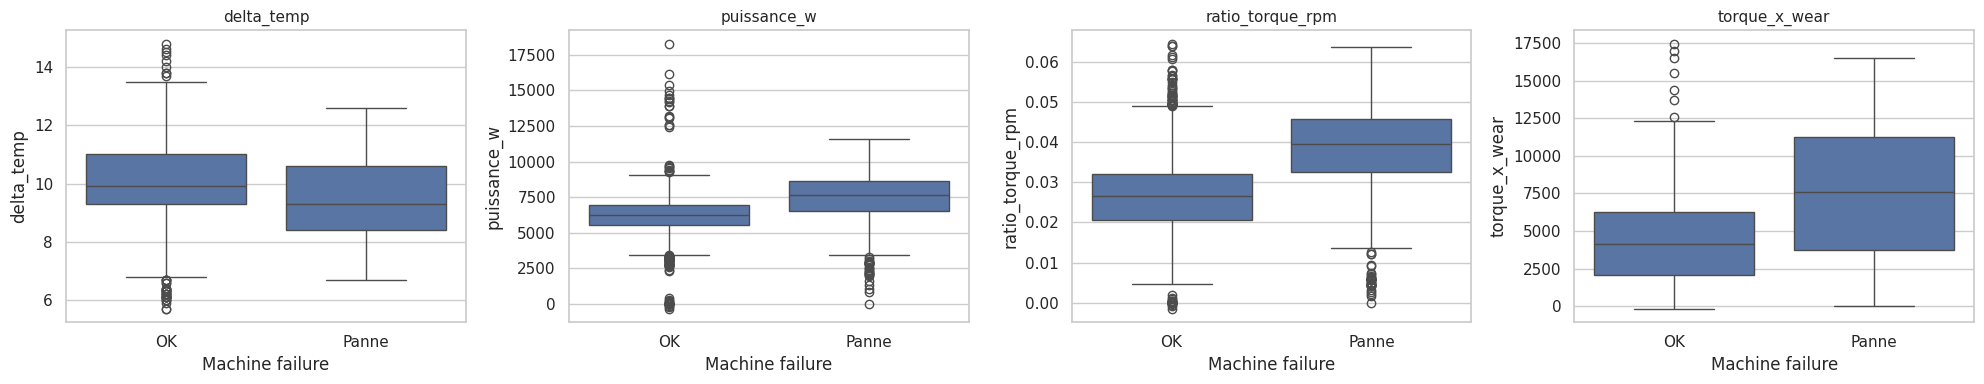

In [6]:
new_features = ["delta_temp", "puissance_w", "ratio_torque_rpm", "torque_x_wear"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(new_features):
    sns.boxplot(data=df, x="Machine failure", y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticklabels(["OK", "Panne"])
plt.tight_layout()
plt.show()

## 7. Corrélation des nouvelles features avec la cible

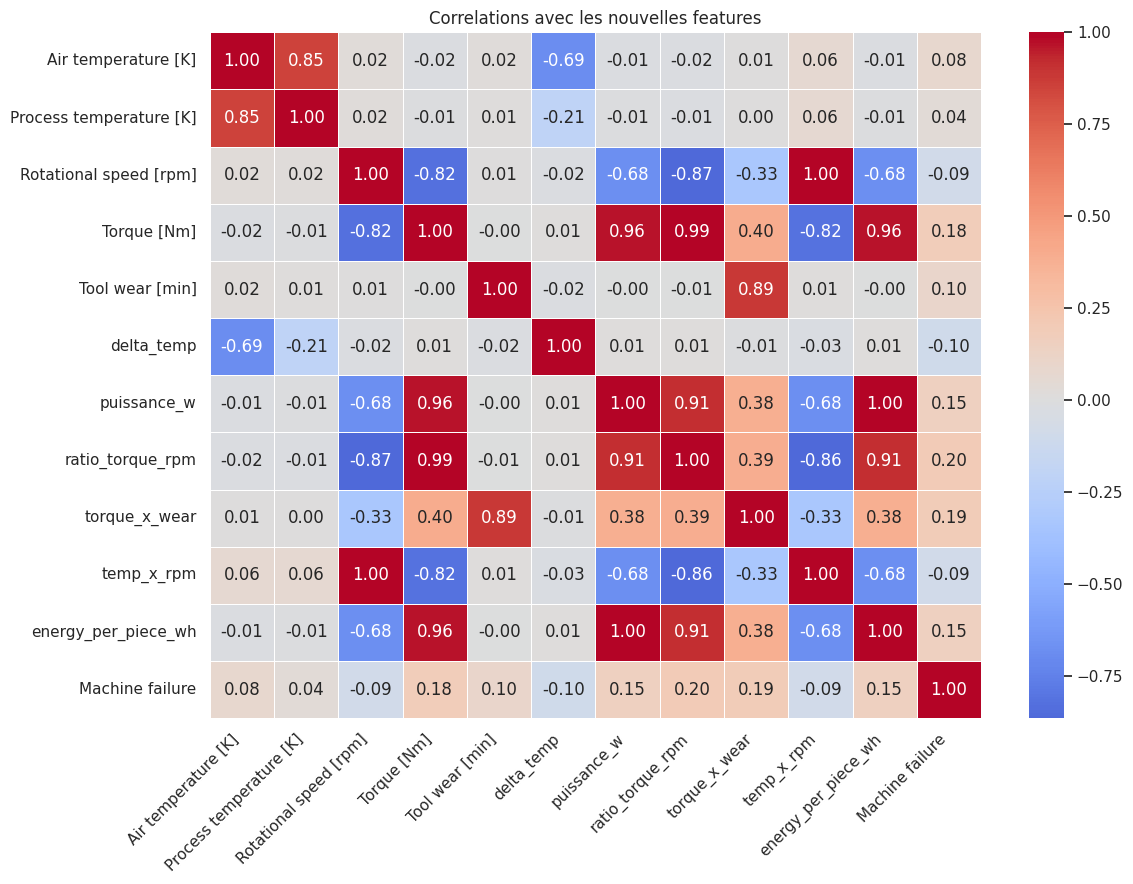


Top correlations avec Machine failure :
ratio_torque_rpm           0.199
torque_x_wear              0.186
Torque [Nm]                0.179
puissance_w                0.149
energy_per_piece_wh        0.149
Tool wear [min]            0.103
delta_temp                -0.096
Rotational speed [rpm]    -0.088
temp_x_rpm                -0.086
Air temperature [K]        0.080
Process temperature [K]    0.038
Name: Machine failure, dtype: float64


In [7]:
num_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
            "Torque [Nm]", "Tool wear [min]",
            "delta_temp", "puissance_w", "ratio_torque_rpm",
            "torque_x_wear", "temp_x_rpm", "energy_per_piece_wh",
            "Machine failure"]

corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlations avec les nouvelles features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nTop correlations avec Machine failure :")
print(corr["Machine failure"].drop("Machine failure").sort_values(key=abs, ascending=False).round(3))

## 8. Export pour le notebook 07 (ML)

In [8]:
df.to_parquet(GOLD_DIR / "features.parquet", index=False)
print(f"Features exportees : {GOLD_DIR / 'features.parquet'}")
print(f"Taille : {(GOLD_DIR / 'features.parquet').stat().st_size / 1024:.1f} Ko")
print(f"Shape  : {df.shape}")
print(f"\nListe des colonnes :")
for col in df.columns:
    print(f"  - {col}")

Features exportees : /home/romaric420/MSPR/data/gold/features.parquet
Taille : 770.4 Ko
Shape  : (10070, 29)

Liste des colonnes :
  - UDI
  - Product ID
  - Air temperature [K]
  - Process temperature [K]
  - Rotational speed [rpm]
  - Torque [Nm]
  - Tool wear [min]
  - Machine failure
  - TWF
  - HDF
  - PWF
  - OSF
  - RNF
  - timestamp
  - pays
  - delta_temp
  - puissance_w
  - ratio_torque_rpm
  - energy_per_piece_wh
  - torque_x_wear
  - temp_x_rpm
  - type_H
  - type_L
  - type_M
  - usine_ES-01
  - usine_FR-01
  - wear_critique
  - wear_neuf
  - wear_use


## 9. Synthèse

### Bilan

- **6 nouvelles features** dérivées créées (delta_temp, puissance_w, ratio, 2 interactions, énergie/pièce)
- **1 feature de binning** (tool_wear_bin)
- **3 variables catégorielles encodées** en OneHot (Type, usine, tool_wear_bin)
- Dataset enrichi exporté dans `data/gold/features.parquet`

### Hypothèses confirmées visuellement

- Le `delta_temp` séparation OK/Panne est très marquée → confirme que HDF est un sous-type dominant
- `torque_x_wear` est plus corrélé à la panne que chacun des composants pris isolément → l'interaction capture un phénomène physique réel
- La catégorie `tool_wear_bin == "critique"` a un taux de panne beaucoup plus élevé

### Suite

- **Notebook 07** : entraînement des modèles ML (LogReg, Random Forest, XGBoost) + MLflow tracking
